# 5 · Planform trade studies

Reproduces the classical result that elliptic loading minimises induced drag and shows how
taper, aspect ratio and sweep move a wing towards or away from it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from aero import plotting as P

P.use_style()
DEG = np.pi / 180
from aero.vortex_lattice_3d.studies import taper_study, sweep_study

optimum taper: VLM 0.45 (e = 0.9960), lifting line 0.35 (e = 0.9875)


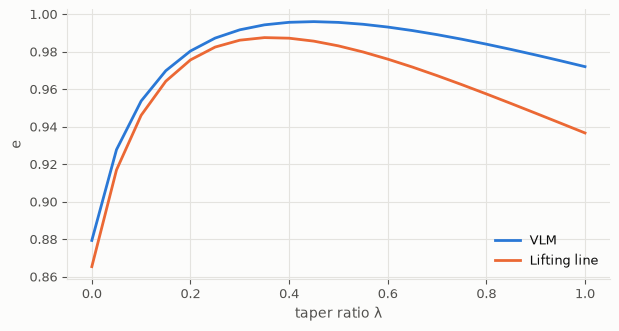

In [2]:
st = taper_study(8, np.linspace(0, 1, 21))
print(f"optimum taper: VLM {st.optimum_vlm:.2f} (e = {st.e_vlm.max():.4f}), "
      f"lifting line {st.optimum_lifting_line:.2f} (e = {st.e_lifting_line.max():.4f})")
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(st.taper, st.e_vlm, color=P.SERIES[0], label="VLM")
ax.plot(st.taper, st.e_lifting_line, color=P.SERIES[1], label="Lifting line")
ax.set_xlabel("taper ratio λ"); ax.set_ylabel("e"); ax.legend();

In [3]:
sweeps = np.array([-30, 0, 30, 45])
for sw, s in zip(sweeps, sweep_study(8, 0.4, sweeps * DEG), strict=True):
    print(f"sweep {sw:+3d} deg: CL_alpha = {s.CL / (4 * DEG):.3f}, e = {s.span_efficiency:.4f}, "
          f"outboard cl/CL = {s.cl_span[5] / s.CL:.3f}")

sweep -30 deg: CL_alpha = 4.195, e = 0.9648, outboard cl/CL = 0.752
sweep  +0 deg: CL_alpha = 4.739, e = 0.9957, outboard cl/CL = 0.853
sweep +30 deg: CL_alpha = 4.362, e = 0.9843, outboard cl/CL = 0.984
sweep +45 deg: CL_alpha = 3.748, e = 0.9632, outboard cl/CL = 1.070


Aft sweep loads the tips (tip-stall tendency), forward sweep unloads them; both reduce the lift-curve slope roughly like $\cos\Lambda$.